# ECON 398 Project Workbook

Authors: *William Clinton Co, Jerrold Huang, Jae Park, Kaiyan Zhang, Irene Berezin*

In [1]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(haven)
library(lubridate)
library(stargazer)
library(units)
library(broom)
library(sf)
library(fixest)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.2"
Warning message:
"package 'dplyr' was built under R version 4.4.2"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 


udunits database from C:/Users/Kaiyan Zhang/AppData/Local/R/win-library/4.4/units/s

### Data Preprocessing (Pulling Data for 2021 Census)

In [9]:
# reading in cancensus data for 2021
library(cancensus)
options(cancensus.api_key='CensusMapper_85cff6944226682c2124e67a6d1cc29c')
options(cancensus.cache_path = "/census_api")

census2021 <- get_census(dataset='CA21', 
regions=list(CSD="5915022"), vectors=c("v_CA21_1","v_CA21_6","v_CA21_386","v_CA21_906","v_CA21_5901", "v_CA21_4410"), 
labels="detailed", 
geo_format="sf", 
level='DA',
use_cache = FALSE)

census2021_clean <- census2021|>
    rename(
        geoid = `GeoUID`,
        households = Households, 
        dwellings = Dwellings, 
        population =  `v_CA21_1: Population, 2021`,
        population_density = `v_CA21_6: Population density per square kilometre`, 
        region = `Region Name`, 
        area_sq_km = `Area (sq km)`, 
        age =  `v_CA21_386: Average age`, 
        income = `v_CA21_906: Median total income of household in 2020 ($)`,
        education = `v_CA21_5901: University certificate or diploma above bachelor level`,
        immigrant = `v_CA21_4410: Immigrants`    
    )|>
    filter(region == "Vancouver")|>
    mutate(immigrant_prop = immigrant/population) |>
    mutate(education_prop = education / population)|>
    mutate(income = income / 100000)|>
    select(name, households, dwellings, population,population_density, region, area_sq_km, age, income, immigrant_prop, education_prop)|>
    glimpse()

census2021_st <- st_sf(census2021_clean, geometry = census2021_clean$geometry, crs = 4326)
census2021_centroid <- st_centroid(census2021_clean)

Querying CensusMapper API...



Downloading: 26 kB     

Querying CensusMapper API...



Downloading: 260 kB     Rows: 0
Columns: 12
$ name               <chr> 
$ households         <int> 
$ dwellings          <int> 
$ population         <dbl> 
$ population_density <dbl> 
$ region             <fct> 
$ area_sq_km         <dbl> 
$ age                <dbl> 
$ income             <dbl> 
$ immigrant_prop     <dbl> 
$ education_prop     <dbl> 
$ geometry           <GEOMETRY [°]> 


### Data Exploration

In [2]:
# Read in the 2016 census data
census2016 <- read_sf("census_index_crime.geojson")|>
    select(- c(crime_count, crime_rate))|>
    glimpse()

Rows: 993
Columns: 17
$ name                 <chr> "59150307", "59150308", "59150309", "59150310", "…
$ households           <int> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,…
$ dwellings            <int> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,…
$ population           <int> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <int> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.4…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index     

In [3]:
# Read in the crime data
crime_data <- read.csv("Original_Crime_data/crime_in_vancouver_census.csv")|>
    select(type, year, month, name, time_category)|>
    filter(!is.na(name))|>
    filter(year >= 2014 & year < 2025)|>
    group_by(year, month, name, type, time_category)|>
    summarise(crime_count = n(), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 207,379
Columns: 7
$ year          <int> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ name          <int> 59150307, 59150308, 59150309, 59150309, 59150309, 591503…
$ type          <chr> "Theft of Vehicle", "Theft from Vehicle", "Mischief", "O…
$ time_category <chr> "night", "night", "day", "day", "night", "night", "night…
$ crime_count   <int> 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,…
$ date          <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014-01…


`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


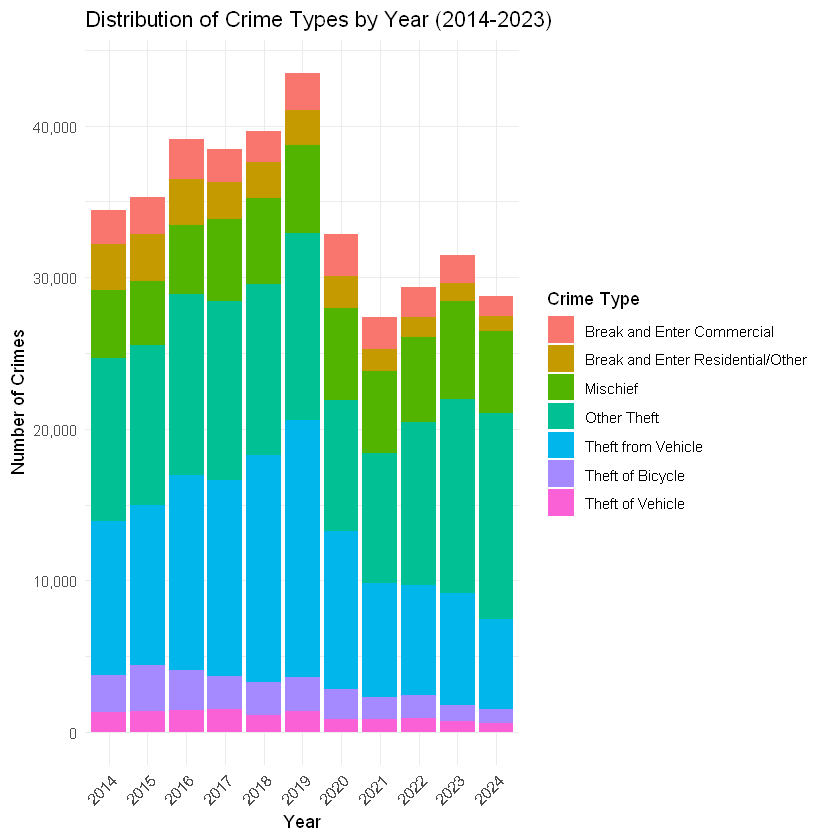

In [4]:
# Visualize the distribution of different types of crimes each year
crime_summary <- crime_data|>
  group_by(year, type)|>
  summarise(total_crimes = sum(crime_count, na.rm = TRUE))|>
  ungroup()

# Create the visualization
ggplot(crime_summary, aes(x = factor(year), y = total_crimes, fill = type)) +
  geom_col(position = "stack") +
  labs(title = "Distribution of Crime Types by Year (2014-2023)",
       x = "Year",
       y = "Number of Crimes",
       fill = "Crime Type") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "right") +
  scale_y_continuous(labels = scales::comma)

The visualization showed some promise in heterogeneous analysis by different crime types, but let's first focus on crime overall

In [5]:
# Create a data summarizing all types of crimes together
crime_trend <- crime_data|>
    group_by(year, month, name, time_category)|>
    summarise(crime_count = sum(crime_count), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 124,088
Columns: 6
$ year          <int> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ name          <int> 59150307, 59150308, 59150309, 59150309, 59150310, 591503…
$ time_category <chr> "night", "night", "day", "night", "night", "night", "nig…
$ crime_count   <int> 1, 1, 2, 1, 4, 3, 1, 1, 2, 2, 1, 1, 1, 3, 1, 2, 2, 1, 3,…
$ date          <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014-01…


In [6]:
census2016_panel <- merge(census2016, crime_trend, by = "name")|>
    arrange(year, month)|>
    glimpse()

Rows: 124,088
Columns: 22
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <int> 254, 203, 269, 269, 283, 181, 203, 402, 402, 170,…
$ dwellings            <int> 273, 223, 299, 299, 310, 199, 211, 418, 418, 181,…
$ population           <int> 632, 501, 745, 745, 536, 532, 562, 1088, 1088, 55…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <int> 630, 500, 745, 745, 540, 530, 560, 1085, 1085, 55…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.8…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [7]:
# Read in the NASA NTL data
ntl_data <- read_csv("NTL_data/NASA_ntl_2012_2024_monthly.csv")|>
    filter(!is.na(ntl_mean))|>
    select(!c(population, population_density))|>
    mutate(date = as.Date(paste0(date, "-01")))|>
    glimpse()

ntl_data$name <- as.character(ntl_data$name)

Rows: 154908 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): date
dbl (7): name, population, population_density, ntl_mean, n_pixels, n_non_na_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 141,792
Columns: 6
$ name               <dbl> 59150307, 59150309, 59150311, 59150313, 59150328, 5…
$ ntl_mean           <dbl> 3.710000, 3.020000, 3.971038, 4.609642, 4.880000, 4…
$ n_pixels           <dbl> 5, 4, 4, 4, 3, 8, 4, 4, 4, 4, 4, 4, 6, 3, 3, 3, 4, …
$ n_non_na_pixels    <dbl> 1, 1, 2, 2, 1, 4, 4, 3, 4, 4, 4, 4, 6, 3, 3, 3, 4, …
$ prop_non_na_pixels <dbl> 0.2000000, 0.2500000, 0.5000000, 0.5000000, 0.33333…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…


In [8]:
# Merge 2 dataframes
census2016_panel <- census2016_panel|>
    left_join(ntl_data, by = c("name", "date"))|>
    glimpse()

Rows: 124,088
Columns: 26
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <int> 254, 203, 269, 269, 283, 181, 203, 402, 402, 170,…
$ dwellings            <int> 273, 223, 299, 299, 310, 199, 211, 418, 418, 181,…
$ population           <int> 632, 501, 745, 745, 536, 532, 562, 1088, 1088, 55…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <int> 630, 500, 745, 745, 540, 530, 560, 1085, 1085, 55…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.8…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [9]:
crime_summary <- census2016_panel|>
    st_drop_geometry()|>
    summarise(mean = mean(crime_count),
    variance = var(crime_count),
    min = min(crime_count),
    max = max(crime_count))

crime_summary

mean,variance,min,max
<dbl>,<dbl>,<int>,<int>
3.064156,58.20041,1,237


Since the crime data is highly volatile and affected by a lot of empty bins, and apparently it has a much larger variance comparing to its mean value. So instead of using the raw variable, we would employ a negative binomial regression to find its expected value given fixed effects of year, month, division, time_category, and we are using population density as an offset variable. 

In [10]:
# load the necessary library
library(MASS)

# Coverting fixed effects as factors
census2016_panel$name <- as.factor(census2016_panel$name)
census2016_panel$year <- as.factor(census2016_panel$year)
census2016_panel$month <- as.factor(census2016_panel$month)
census2016_panel$time_category <- as.factor(census2016_panel$time_category)

# Implementing the negative binomial regression
model_nb <- glm.nb(crime_count ~ name + year + month + time_category + offset(log(population_density)),
                   data = census2016_panel)

summary(model_nb)

Warning message:
"package 'MASS' was built under R version 4.4.2"

Attaching package: 'MASS'


The following object is masked from 'package:dplyr':

    select





Call:
glm.nb(formula = crime_count ~ name + year + month + time_category + 
    offset(log(population_density)), data = census2016_panel, 
    init.theta = 23.5746772, link = log)

Coefficients:
                    Estimate Std. Error  z value Pr(>|z|)    
(Intercept)        -7.344351   0.073238 -100.281  < 2e-16 ***
name59150308       -0.783176   0.107772   -7.267 3.68e-13 ***
name59150309       -1.005584   0.092636  -10.855  < 2e-16 ***
name59150310       -0.498105   0.087453   -5.696 1.23e-08 ***
name59150311       -1.283417   0.106802  -12.017  < 2e-16 ***
name59150312       -1.202078   0.108511  -11.078  < 2e-16 ***
name59150313       -0.930968   0.099157   -9.389  < 2e-16 ***
name59150328       -0.153998   0.104785   -1.470 0.141653    
name59150329       -0.363436   0.099416   -3.656 0.000256 ***
name59150330       -1.307719   0.138549   -9.439  < 2e-16 ***
name59150331       -0.966697   0.109094   -8.861  < 2e-16 ***
name59150332       -1.107741   0.111352   -9.948  < 2e-16 **

In [11]:
census2016_panel$expected_crime <- predict(model_nb, type = "response")

glimpse(census2016_panel)

Rows: 124,088
Columns: 27
$ name                 <fct> 59150307, 59150308, 59150309, 59150309, 59150310,…
$ households           <int> 254, 203, 269, 269, 283, 181, 203, 402, 402, 170,…
$ dwellings            <int> 273, 223, 299, 299, 310, 199, 211, 418, 418, 181,…
$ population           <int> 632, 501, 745, 745, 536, 532, 562, 1088, 1088, 55…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <int> 630, 500, 745, 745, 540, 530, 560, 1085, 1085, 55…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.8…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [12]:
NBsummary <- census2016_panel|>
    st_drop_geometry()|>
    group_by(time_category)|>
    summarise(mean = mean(expected_crime),
    variance = var(expected_crime),
    min = min(expected_crime),
    max = max(expected_crime))

NBsummary

time_category,mean,variance,min,max
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
day,2.958655,46.87939,0.7847472,134.7281
night,3.136487,53.62122,0.9542959,171.3460


In [20]:
# Save the data so we can start from here next time
census2016_panel <- census2016_panel|>
    st_drop_geometry()|>
    dplyr::select(-c(households, dwellings, region))

write_csv(census2016_panel, "census_2016_panel.csv")

### Panel Fixed Effect Model

With the data ready, we can run our first panel fixed effect model.

In [22]:
census2016_panel <- read_csv("census_2016_panel.csv")

Rows: 124088 Columns: 23
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (1): time_category
dbl  (21): name, population, population_density, area_sq_km, age, income, im...
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [23]:
# Making necessary changes to the data
census2016_panel_night <- census2016_panel|>
    filter(time_category == "night")|>
    filter(year %in% c(2014, 2015, 2016, 2017, 2018))|>
    mutate(month = factor(month, levels = c("6", setdiff(sort(unique(as.character(month))), "6"))))|>
    mutate(income = as.numeric(income), immigrant_prop = as.numeric(immigrant_prop), education_prop = as.numeric(education_prop))|>
    filter(!is.na(income), !is.na(education_prop), !is.na(immigrant_prop))|>
    glimpse()

Rows: 35,806
Columns: 23
$ name                 <dbl> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 556, 506, 683…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 555, 510, 680…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ education_prop       <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index          <dbl> 2.751678, 2.575631, 2.986096, 3.239346, 2.298736,…
$ bus_index            <dbl> 1.314003, 1.455674, 1.812310, 3.605736, 1.782943,…
$ cultural_space_index <dbl> 1.286579, 1.349792, 1.485976, 1.382670, 1.501593,…
$ mean_land_val

In [29]:
model0 <- expected_crime ~ ntl_mean | name + year + month

model_fe0 <- feols(model0, data = census2016_panel_night)

summary(model_fe0)

NOTE: 2,907 observations removed because of NA values (RHS: 2,907).



OLS estimation, Dep. Var.: expected_crime
Observations: 32,899
Fixed-effects: name: 992,  year: 5,  month: 11
Standard-errors: Clustered (name) 
          Estimate Std. Error  t value Pr(>|t|)    
ntl_mean -0.007802   0.004439 -1.75761 0.079123 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 0.367878     Adj. R2: 0.997424
                 Within R2: 0.001974

In [25]:
model1 <- expected_crime ~ ntl_mean + population_density + income + immigrant_prop + education_prop + 
    school_index + bus_index + cultural_space_index | year + month

model_fe1 <- feols(model1, data = census2016_panel_night)

summary(model_fe1)

NOTE: 2,907 observations removed because of NA values (RHS: 2,907).



OLS estimation, Dep. Var.: expected_crime
Observations: 32,899
Fixed-effects: year: 5,  month: 11
Standard-errors: Clustered (year) 
                      Estimate Std. Error   t value   Pr(>|t|)    
ntl_mean              0.705455 0.03342037  21.10854 2.9775e-05 ***
population_density   -0.000214 0.00000274 -77.95208 1.6232e-07 ***
income               -0.557178 0.15668682  -3.55600 2.3671e-02 *  
immigrant_prop        3.796630 0.21975551  17.27661 6.5869e-05 ***
education_prop        3.343624 0.19806273  16.88164 7.2177e-05 ***
school_index         -1.513136 0.02808219 -53.88240 7.1018e-07 ***
bus_index             1.317581 0.02040806  64.56183 3.4479e-07 ***
cultural_space_index  0.977345 0.05383160  18.15560 5.4122e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 6.38876     Adj. R2: 0.246348
                Within R2: 0.246604

In [27]:
model_count0 <- crime_count ~ ntl_mean | name + year + month

model_fe_count0 <- feols(model_count0, data = census2016_panel_night)

summary(model_fe_count0)

NOTE: 2,907 observations removed because of NA values (RHS: 2,907).



OLS estimation, Dep. Var.: crime_count
Observations: 32,899
Fixed-effects: name: 992,  year: 5,  month: 11
Standard-errors: Clustered (name) 
         Estimate Std. Error  t value Pr(>|t|) 
ntl_mean 0.009762   0.013044 0.748352  0.45443 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2.29169     Adj. R2: 0.899787
                Within R2: 7.979e-5

In [ ]:
model_count1 <- crime_count ~ ntl_mean + population_density + income + immigrant_prop + education_prop + 
    school_index + bus_index + cultural_space_index | year + month

model_fe_count1 <- feols(model_count1, data = census2016_panel_night)

summary(model_fe_count1)

NOTE: 2,907 observations removed because of NA values (RHS: 2,907).



OLS estimation, Dep. Var.: crime_count
Observations: 32,899
Fixed-effects: year: 5,  month: 11
Standard-errors: Clustered (year) 
                      Estimate Std. Error   t value   Pr(>|t|)    
ntl_mean              0.713822   0.048483  14.72300 1.2386e-04 ***
population_density   -0.000200   0.000013 -15.11909 1.1155e-04 ***
income               -0.291498   0.164592  -1.77104 1.5126e-01    
immigrant_prop        3.435791   0.256555  13.39204 1.7980e-04 ***
education_prop        3.046198   0.247689  12.29846 2.5110e-04 ***
school_index         -1.407865   0.087976 -16.00283 8.9154e-05 ***
bus_index             1.032683   0.061277  16.85259 7.2670e-05 ***
cultural_space_index  1.169248   0.073383  15.93353 9.0695e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 6.35705     Adj. R2: 0.251956
                Within R2: 0.252   